# Dataset

In [1]:
import pandas as pd

In [2]:
def load_data(filepath="data/Reviews.csv", n_samples=3000):
    df = pd.read_csv(filepath, nrows=n_samples)
    df = df[["Text", "Summary", "Score"]].dropna()
    df["full_review"] = df["Summary"] + ". " + df["Text"]
    return df

def get_documents(df):
    return df["full_review"].tolist()

def save_sample(df, out_path="data/sample_500.csv"):
    df.head(500).to_csv(out_path, index=False)

if __name__ == "__main__":
    df = load_data()
    print(f"Loaded {len(df)} reviews")
    save_sample(df)
    print("Sample saved to data/sample_500.csv")

Loaded 3000 reviews
Sample saved to data/sample_500.csv


# Preprocessing

In [3]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer


import nltk


nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [4]:
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
tokenizer = RegexpTokenizer(r"\w+")

In [5]:
def preprocess_text(text):
    """
    Text preprocessing pipeline for Project 2 (Search Engine):
    - Lowercasing
    - Removing punctuation
    - Removing numbers
    - Tokenization
    - Stopword removal
    - Lemmatization
    """

    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 3. Tokenization (no punkt, no errors)
    tokens = tokenizer.tokenize(text)

    # 4. Remove stopwords
    tokens = [t for t in tokens if t not in STOPWORDS]

    # 5. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

In [6]:
def preprocess_documents(documents):
    return [preprocess_text(doc) for doc in documents]

# TF-IDF Cosine Similarity Search

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from src.preprocessing import preprocess_text

car running fast


In [8]:
def build_tfidf_improved(cleaned_docs: list):
    """
    Build and fit an improved TF-IDF matrix.

    Improvements over baseline:
    - ngram_range=(1,2)  : unigrams + bigrams for richer features
    - sublinear_tf=True  : log-normalised TF dampens high-frequency terms
    - max_df=0.85        : removes near-universal stopwords missed by preprocessing
    - min_df=2           : removes hapax legomena (noise terms)
    - max_features=15000 : focused vocabulary, faster inference

    Parameters
    ----------
    cleaned_docs : list of str – preprocessed documents

    Returns
    -------
    vectorizer   : fitted TfidfVectorizer (improved)
    tfidf_matrix : sparse matrix of shape (n_docs, n_features)
    """
    vectorizer = TfidfVectorizer(
        ngram_range=(1,2),
        sublinear_tf=True,
        max_df=0.90,
        min_df=1,
        max_features=15000,
    )
    tfidf_matrix = vectorizer.fit_transform(cleaned_docs)
    print(f"[TF-IDF Improved] Matrix shape: {tfidf_matrix.shape}")
    return vectorizer, tfidf_matrix

In [9]:
def search_tfidf(query: str,
                 vectorizer,
                 tfidf_matrix,
                 documents: list,
                 top_k: int = 5) -> list:
    """
    Return the top-k most relevant documents for a query using
    TF-IDF vectors + cosine similarity.

    Works with both the original and improved vectorizer/matrix.

    Parameters
    ----------
    query        : str   – raw user query
    vectorizer   : fitted TfidfVectorizer (original or improved)
    tfidf_matrix : sparse matrix from build_tfidf() or build_tfidf_improved()
    documents    : list of str – original (un-cleaned) documents
    top_k        : int   – how many results to return (default 5)

    Returns
    -------
    list of dict – each dict has keys: 'rank', 'score', 'document'
    """
    cleaned_query = preprocess_text(query)
    if not cleaned_query:
        cleaned_query_str = query.lower()
    else:
        cleaned_query_str = " ".join(cleaned_query)

    query_vector = vectorizer.transform([cleaned_query_str])
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    ranked_indices = scores.argsort()[::-1][:top_k]

    results = []
    for rank, idx in enumerate(ranked_indices, start=1):
        results.append({
            "rank": rank,
            "score": round(float(scores[idx]), 4),
            "document": documents[idx],
        })

    return results

# TF-IDF BERT

In [10]:
!pip install sentence-transformers

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import CrossEncoder
from src.preprocessing import preprocess_text

In [11]:
def build_tfidf_bert(cleaned_docs: list, documents: list = None):
    """
    Build TF-IDF matrix and load the BERT Cross-Encoder model.

    Parameters
    ----------
    cleaned_docs : list of str – preprocessed documents (from preprocess_documents)
    documents    : list of str – original documents (unused, kept for API consistency)

    Returns
    -------
    tuple: (cross_encoder, vectorizer, tfidf_matrix)
        cross_encoder : CrossEncoder model
        vectorizer    : fitted TfidfVectorizer
        tfidf_matrix  : sparse TF-IDF matrix
    """
    # Build TF-IDF
    vectorizer = TfidfVectorizer(
        ngram_range=(1,2),
        sublinear_tf=True,
        max_df=0.85,
        min_df=1,
        max_features=15000,
    )
    tfidf_matrix = vectorizer.fit_transform(cleaned_docs)
    print(f"[TF-IDF+BERT] TF-IDF matrix shape: {tfidf_matrix.shape}")

    # Load Cross-Encoder
    print("[TF-IDF+BERT] Loading model: cross-encoder/ms-marco-MiniLM-L-6-v2")
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    print("[TF-IDF+BERT] Model loaded.")

    return cross_encoder, vectorizer, tfidf_matrix

In [12]:
def search_tfidf_bert(query: str,
                      tfidf_bert_model: tuple,
                      documents: list,
                      top_k: int = 5,
                      candidate_k: int = 50) -> list:
    """
    2-stage search: TF-IDF retrieval → BERT Cross-Encoder re-ranking.

    Parameters
    ----------
    query            : str   – raw user query
    tfidf_bert_model : tuple – (cross_encoder, vectorizer, tfidf_matrix)
                               returned by build_tfidf_bert()
    documents        : list of str – original (un-cleaned) documents
    top_k            : int   – final results to return (default 5)
    candidate_k      : int   – how many TF-IDF candidates to re-rank (default 50)

    Returns
    -------
    list of dict  – each dict has keys: 'rank', 'score', 'document'
                    'score' is the BERT Cross-Encoder relevance score.
    """
    cross_encoder, vectorizer, tfidf_matrix = tfidf_bert_model

    # ── Stage 1: TF-IDF fast retrieval ──────────────────────────────────────
    cleaned_tokens = preprocess_text(query)
    if not cleaned_tokens:
        cleaned_query_str = query.lower()
    else:
        cleaned_query_str = " ".join(cleaned_tokens)

    query_vector = vectorizer.transform([cleaned_query_str])
    tfidf_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    n_candidates = min(candidate_k, len(documents))
    candidate_indices = tfidf_scores.argsort()[::-1][:n_candidates]
    candidate_docs = [documents[i] for i in candidate_indices]

    # ── Stage 2: BERT Cross-Encoder re-ranking ──────────────────────────────
    pairs = [(query, doc) for doc in candidate_docs]
    bert_scores = cross_encoder.predict(pairs)

    sorted_order = np.argsort(bert_scores)[::-1][:top_k]

    results = []
    for rank, order_idx in enumerate(sorted_order, start=1):
        results.append({
            "rank": rank,
            "score": round(float(bert_scores[order_idx]), 4),
            "document": candidate_docs[order_idx],
        })

    return results

# Word2Vec Cosine Similarity Search

In [13]:
!pip install gensim

import numpy as np
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from src.preprocessing import preprocess_text

In [14]:
def _average_vector(text: str, model: Word2Vec, vector_size: int) -> np.ndarray:
    """
    Return the mean Word2Vec vector for all *known* words in `text`.
    If no word is found in the vocabulary, return a zero vector.
    """
    tokens = text.split() if isinstance(text, str) else text
    known = [t for t in tokens if t in model.wv]

    if not known:
        return np.zeros(vector_size)

    vectors = np.stack([model.wv[t] for t in known])
    return vectors.mean(axis=0)

In [15]:
def build_w2v_improved(cleaned_docs: list):
    """
    Train an improved Word2Vec model.

    Improvements over baseline:
    - vector_size=200  : richer 200-dim representations vs 100
    - window=3         : tighter context window → sharper word associations
    - epochs=30        : 3× more training for better convergence
    - min_count=1      : keeps domain-specific rare food words
    - sg=1             : Skip-gram (better than CBOW for specific/rare words)

    Parameters
    ----------
    cleaned_docs : list of str – preprocessed documents

    Returns
    -------
    w2v_model   : trained gensim Word2Vec model (improved)
    doc_vectors : np.ndarray of shape (n_docs, 200)
    """
    vector_size = 200
    tokenised = [doc.split() for doc in cleaned_docs]

    print("[Word2Vec Improved] Training model (Skip-gram, 200d, 30 epochs)...")
    w2v_model = Word2Vec(
        sentences=tokenised,
        vector_size=vector_size,
        window=3,
        min_count=1,
        workers=4,
        epochs=30,
        sg=1,  # Skip-gram
    )
    vocab_size = len(w2v_model.wv)
    print(f"[Word2Vec Improved] Vocabulary size : {vocab_size:,}")
    print(f"[Word2Vec Improved] Vector size     : {vector_size}")

    doc_vectors = np.stack([
        _average_vector(doc, w2v_model, vector_size)
        for doc in cleaned_docs
    ])
    print(f"[Word2Vec Improved] Document matrix : {doc_vectors.shape}")

    return w2v_model, doc_vectors

In [16]:
def search_w2v(query: str,
               w2v_model: Word2Vec,
               doc_vectors: np.ndarray,
               documents: list,
               top_k: int = 5) -> list:
    """
    Return the top-k most relevant documents using Word2Vec + cosine similarity.
    Works with both original and improved models.
    """
    vector_size = w2v_model.vector_size

    cleaned_query = preprocess_text(query)
    if not cleaned_query:
        cleaned_query = query.lower()


    query_vector = _average_vector(cleaned_query, w2v_model, vector_size)

    if not np.any(query_vector):
        print("[Word2Vec] Warning: no query words found in vocabulary.")
        return []

    scores = cosine_similarity(
        query_vector.reshape(1, -1),
        doc_vectors
    ).flatten()

    ranked_indices = scores.argsort()[::-1][:top_k]

    results = []
    for rank, idx in enumerate(ranked_indices, start=1):
        results.append({
            "rank": rank,
            "score": round(float(scores[idx]), 4),
            "document": documents[idx],
        })

    return results


# Alias for backward compatibility
search_w2v_cosine = search_w2v

# Word2Vec BERT

In [17]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import CrossEncoder
from src.preprocessing import preprocess_text
from src.w2v_cosine_search import build_w2v_improved

In [18]:
def build_w2v_bert(cleaned_docs: list, documents: list = None):
    """
    Train a Word2Vec model, encode documents, and load the BERT Cross-Encoder.

    Parameters
    ----------
    cleaned_docs : list of str – preprocessed documents (from preprocess_documents)
    documents    : list of str – original documents (unused, kept for API consistency)

    Returns
    -------
    tuple: (cross_encoder, w2v_model, doc_vectors)
        cross_encoder : CrossEncoder model
        w2v_model     : trained gensim Word2Vec model
        doc_vectors   : np.ndarray of shape (n_docs, vector_size)
    """
    # Train Word2Vec and encode documents
    w2v_model, doc_vectors = build_w2v_improved(cleaned_docs)

    # Load Cross-Encoder
    print("[W2V+BERT] Loading Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2")
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    print("[W2V+BERT] Model loaded.")

    return cross_encoder, w2v_model, doc_vectors

In [19]:
def search_w2v_bert(query: str,
                    w2v_bert_model: tuple,
                    documents: list,
                    top_k: int = 5,
                    candidate_k: int = 50) -> list:
    """
    2-stage search: Word2Vec retrieval → BERT Cross-Encoder re-ranking.

    Parameters
    ----------
    query          : str   – raw user query
    w2v_bert_model : tuple – (cross_encoder, w2v_model, doc_vectors)
                             returned by build_w2v_bert()
    documents      : list of str – original (un-cleaned) documents
    top_k          : int   – final results to return (default 5)
    candidate_k    : int   – how many W2V candidates to re-rank (default 50)

    Returns
    -------
    list of dict  – each dict has keys: 'rank', 'score', 'document'
                    'score' is the BERT Cross-Encoder relevance score.
    """
    cross_encoder, w2v_model, doc_vectors = w2v_bert_model
    vector_size = w2v_model.vector_size

    # ── Stage 1: Word2Vec fast retrieval ─────────────────────────────────────
    cleaned_query = preprocess_text(query)
    if not cleaned_query:
        cleaned_query = query.lower()

    query_vector = _average_vector(cleaned_query, w2v_model, vector_size)

    if not np.any(query_vector):
        print("[W2V+BERT] Warning: no query words in W2V vocabulary. "
              "Returning empty results.")
        return []

    w2v_scores = cosine_similarity(
        query_vector.reshape(1, -1),
        doc_vectors
    ).flatten()

    n_candidates = min(candidate_k, len(documents))
    candidate_indices = w2v_scores.argsort()[::-1][:n_candidates]
    candidate_docs = [documents[i] for i in candidate_indices]

    # ── Stage 2: BERT Cross-Encoder re-ranking ───────────────────────────────
    pairs = [(query, doc) for doc in candidate_docs]
    bert_scores = cross_encoder.predict(pairs)

    sorted_order = np.argsort(bert_scores)[::-1][:top_k]

    results = []
    for rank, order_idx in enumerate(sorted_order, start=1):
        results.append({
            "rank": rank,
            "score": round(float(bert_scores[order_idx]), 4),
            "document": candidate_docs[order_idx],
        })

    return results

# Embeddings

In [20]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [21]:
def build_embeddings(documents: list):
    """
    Encode all documents using a sentence transformer model.

    Parameters
    ----------
    documents : list of str – original (un-cleaned) documents

    Returns
    -------
    model      : SentenceTransformer – loaded model
    embeddings : np.ndarray – shape (n_docs, 384)
    """
    model = SentenceTransformer('all-MiniLM-L6-v2')
    print("[Embeddings] Encoding documents...")
    embeddings = model.encode(documents, show_progress_bar=True)
    print(f"[Embeddings] Matrix shape : {embeddings.shape}")
    return model, embeddings

In [22]:
def search_embeddings(query: str,
                    model,
                    embeddings,
                    documents: list,
                    top_k: int = 5) -> list:
    """
    Return the top-k most relevant documents using semantic similarity.

    Parameters
    ----------
    query      : str   – raw user query
    model      : fitted SentenceTransformer
    embeddings : np.ndarray from build_embeddings()
    documents  : list of str – original documents
    top_k      : int   – how many results to return (default 5)

    Returns
    -------
    list of dict – each dict has keys: 'rank', 'score', 'document'
    """
    # Encode the query
    query_embedding = model.encode([query])

    # Cosine similarity between query and all documents
    scores = cosine_similarity(query_embedding, embeddings).flatten()

    # Rank descending
    ranked_indices = scores.argsort()[::-1][:top_k]

    # Build result list
    results = []
    for rank, idx in enumerate(ranked_indices, start=1):
        results.append({
            "rank"    : rank,
            "score"   : round(float(scores[idx]), 4),
            "document": documents[idx],
        })

    return results

# Evaluation

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

try:
    from src.tfidf_search      import search_tfidf
    from src.w2v_cosine_search import search_w2v
    from src.tfidf_bert_search import search_tfidf_bert
    from src.w2v_bert_search   import search_w2v_bert
except ModuleNotFoundError:
    from tfidf_search      import search_tfidf
    from w2v_cosine_search import search_w2v
    from tfidf_bert_search import search_tfidf_bert
    from w2v_bert_search   import search_w2v_bert

In [24]:
def _is_relevant(document, keywords):
    return int(any(kw in document.lower() for kw in keywords))

def _build_relevant_flags(query, results):
    keywords = QUERY_KEYWORDS.get(query,
               [w.lower() for w in query.split() if len(w) > 3])
    return [_is_relevant(r["document"], keywords) for r in results]

In [25]:
def precision_at_k(relevant_flags, k):
    """Precision@k = relevant in top-k / k"""
    if k <= 0:
        return 0.0
    return round(sum(relevant_flags[:k]) / k, 4)

def recall_at_k(relevant_flags, total_relevant, k):
    """Recall@k = relevant in top-k / total relevant in corpus (capped at k for IR)"""
    if total_relevant <= 0:
        return 0.0
    # In IR without a full corpus scan, we use min(total_relevant, k) as denominator
    denominator = min(total_relevant, k)
    return round(sum(relevant_flags[:k]) / denominator, 4)

def f1_at_k(p, r):
    """F1@k = harmonic mean of Precision@k and Recall@k"""
    if (p + r) == 0:
        return 0.0
    return round(2 * p * r / (p + r), 4)

def confusion_matrix_at_k(relevant_flags, k):
    """
    Binary confusion matrix for top-k results.
    Each result is either:
        TP: retrieved AND relevant
        FP: retrieved AND not relevant
    For the remaining (corpus - k) documents (not retrieved):
        FN: not retrieved AND relevant  → estimated as total_relevant - TP
        TN: not retrieved AND not relevant → corpus_size - TP - FP - FN
    Since we don't scan the full corpus, we return only TP and FP from top-k.

    Returns
    -------
    dict with keys: TP, FP, retrieved_relevant, retrieved_total
    """
    flags = relevant_flags[:k]
    tp = sum(flags)
    fp = k - tp
    return {"TP": tp, "FP": fp, "k": k}

In [26]:
def evaluate_model(model_name, results, relevant_flags, k=5):
    """Print and return Precision@k, Recall@k, F1@k for one model."""
    p = precision_at_k(relevant_flags, k)
    total_relevant = sum(relevant_flags)          # relevant found in top-k (IR convention)
    r = recall_at_k(relevant_flags, total_relevant, k)
    f = f1_at_k(p, r)
    cm = confusion_matrix_at_k(relevant_flags, k)

    print(f"\n  -- {model_name} --")
    print(f"  Precision@{k} = {p:.4f}  |  Recall@{k} = {r:.4f}  |  F1@{k} = {f:.4f}")
    print(f"  Confusion Matrix (top-{k}): TP={cm['TP']}  FP={cm['FP']}")
    print(f"  {'Rank':<6} {'Score':<8} {'Relevant':<10} Document (first 80 chars)")
    print(f"  {'-'*6} {'-'*8} {'-'*10} {'-'*50}")
    for i, result in enumerate(results[:k]):
        rel = "YES" if relevant_flags[i] == 1 else "NO "
        doc = result["document"][:80].replace("\n", " ")
        print(f"  #{result['rank']:<5} {result['score']:<8.4f} {rel:<10} {doc}...")

    return p, r, f

In [27]:
MODEL_COLORS = {
    "TF-IDF + Cosine" : "#4C72B0",
    "W2V + Cosine"    : "#55A868",
    "TF-IDF + BERT"   : "#DD8452",
    "W2V + BERT"      : "#C44E52",
}
MODEL_LABELS = {
    "TF-IDF + Cosine" : "TF-IDF + Cosine\n(Baseline)",
    "W2V + Cosine"    : "W2V + Cosine\n(Baseline)",
    "TF-IDF + BERT"   : "TF-IDF + BERT\n(Advanced)",
    "W2V + BERT"      : "W2V + BERT\n(Advanced)",
}

In [28]:
def evaluate(queries, vectorizer, tfidf_matrix,
             w2v_model, w2v_vectors,
             tfidf_bert_model, w2v_bert_model,
             cleaned_docs, documents, k=5):
    """
    Evaluate all 4 models on the given queries.
    Returns dict of scores with Precision, Recall, F1 per model.
    """
    metrics = {
        m: {"precision": [], "recall": [], "f1": []}
        for m in ["TF-IDF + Cosine", "W2V + Cosine", "TF-IDF + BERT", "W2V + BERT"]
    }

    print("\n" + "="*75)
    print(f"  EVALUATION  --  Precision / Recall / F1  @{k}  (4 Models)")
    print("="*75)

    for query in queries:
        print(f"\n>>> Query: \"{query}\"")

        r1 = search_tfidf(query, vectorizer, tfidf_matrix, documents, top_k=k)
        f1 = _build_relevant_flags(query, r1)
        p, r, f = evaluate_model("TF-IDF + Cosine (Baseline)", r1, f1, k)
        metrics["TF-IDF + Cosine"]["precision"].append(p)
        metrics["TF-IDF + Cosine"]["recall"].append(r)
        metrics["TF-IDF + Cosine"]["f1"].append(f)

        r2 = search_w2v(query, w2v_model, w2v_vectors, documents, top_k=k)
        f2 = _build_relevant_flags(query, r2)
        p, r, f = evaluate_model("W2V + Cosine (Baseline)", r2, f2, k)
        metrics["W2V + Cosine"]["precision"].append(p)
        metrics["W2V + Cosine"]["recall"].append(r)
        metrics["W2V + Cosine"]["f1"].append(f)

        r3 = search_tfidf_bert(query, tfidf_bert_model, documents, top_k=k)
        f3 = _build_relevant_flags(query, r3)
        p, r, f = evaluate_model("TF-IDF + BERT (Advanced)", r3, f3, k)
        metrics["TF-IDF + BERT"]["precision"].append(p)
        metrics["TF-IDF + BERT"]["recall"].append(r)
        metrics["TF-IDF + BERT"]["f1"].append(f)

        r4 = search_w2v_bert(query, w2v_bert_model, documents, top_k=k)
        f4 = _build_relevant_flags(query, r4)
        p, r, f = evaluate_model("W2V + BERT (Advanced)", r4, f4, k)
        metrics["W2V + BERT"]["precision"].append(p)
        metrics["W2V + BERT"]["recall"].append(r)
        metrics["W2V + BERT"]["f1"].append(f)

    _print_comparison_table(queries, metrics, k)
    _plot_comparison(queries, metrics, k)
    _plot_confusion_matrices(queries, metrics, k)
    return metrics

In [29]:
def _print_comparison_table(queries, metrics, k):
    models = list(metrics.keys())
    col_w  = 28

    for metric_name in ["precision", "recall", "f1"]:
        print("\n" + "="*90)
        print(f"  COMPARISON TABLE  --  {metric_name.upper()}@{k}")
        print("="*90)
        header = f"  {'Query':<{col_w}}"
        for m in models:
            header += f" {m:>18}"
        header += f"  {'Winner':>18}"
        print(header)
        print("  " + "-"*88)

        for i, query in enumerate(queries):
            row_scores = {m: metrics[m][metric_name][i] for m in models}
            winner = max(row_scores, key=row_scores.get)
            short_q = query[:col_w-1] if len(query) >= col_w else query
            row = f"  {short_q:<{col_w}}"
            for m in models:
                row += f" {row_scores[m]:>18.4f}"
            row += f"  {winner:>18}"
            print(row)

        avgs = {m: float(np.mean(metrics[m][metric_name])) for m in models}
        winner = max(avgs, key=avgs.get)
        print("  " + "─"*88)
        row = f"  {'AVERAGE':<{col_w}}"
        for m in models:
            row += f" {avgs[m]:>18.4f}"
        row += f"  {winner:>18}"
        print(row)
        print("="*90)

In [30]:
def _plot_comparison(queries, metrics, k):
    models = list(metrics.keys())
    colors = [MODEL_COLORS[m] for m in models]
    labels = [MODEL_LABELS[m] for m in models]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"Search Engine Evaluation  –  @{k}  (4 Models)",
                 fontsize=14, fontweight="bold")

    for ax, metric_name in zip(axes, ["precision", "recall", "f1"]):
        avgs = [float(np.mean(metrics[m][metric_name])) for m in models]
        bars = ax.bar(labels, avgs, color=colors,
                      edgecolor="white", linewidth=0.8, width=0.55)
        winner_idx = int(np.argmax(avgs))
        for i, (bar, val) in enumerate(zip(bars, avgs)):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                    f"{val:.4f}", ha="center", va="bottom",
                    fontsize=9, fontweight="bold")
            if i == winner_idx:
                bar.set_edgecolor("gold")
                bar.set_linewidth(2.5)

        ax.set_ylabel(f"Avg {metric_name.title()}@{k}")
        ax.set_title(f"{metric_name.title()}@{k} – All Models")
        ax.set_ylim(0, 1.25)
        ax.yaxis.grid(True, linestyle="--", alpha=0.6)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", labelsize=7)

    ax.legend(handles=[mpatches.Patch(edgecolor="gold", facecolor="none",
              linewidth=2.5, label="Winner")], fontsize=9)

    plt.tight_layout()
    plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("\n  Chart saved → evaluation_results.png")

In [31]:
def _plot_confusion_matrices(queries, metrics, k):
    """
    For each model, show a stacked bar: TP (relevant retrieved) vs FP (not relevant retrieved).
    Since recall is already computed from top-k relevant, TP = round(recall * min(relevant, k)).
    We derive TP from precision: TP = precision * k.
    """
    models = list(metrics.keys())
    n_queries = len(queries)
    short_q = [q[:18] + "..." if len(q) > 18 else q for q in queries]
    x = np.arange(n_queries)
    width = 0.18
    offsets = [-1.5, -0.5, 0.5, 1.5]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"Confusion Matrix Summary (Top-{k} Retrieved)",
                 fontsize=13, fontweight="bold")

    # ── Subplot 1: TP vs FP per query per model (stacked) ───────────────────
    ax1 = axes[0]
    for (model, color), offset in zip(MODEL_COLORS.items(), offsets):
        tp_vals = [round(metrics[model]["precision"][i] * k) for i in range(n_queries)]
        fp_vals = [k - tp for tp in tp_vals]
        bars_tp = ax1.bar(x + offset * width, tp_vals, width,
                          color=color, label=MODEL_LABELS[model].replace("\n", " "),
                          edgecolor="white", linewidth=0.5)
        ax1.bar(x + offset * width, fp_vals, width,
                bottom=tp_vals, color=color, alpha=0.25,
                edgecolor="white", linewidth=0.5)

    ax1.set_xlabel("Query")
    ax1.set_ylabel(f"Count (out of top-{k})")
    ax1.set_title(f"TP (solid) vs FP (faded) per Query")
    ax1.set_xticks(x)
    ax1.set_xticklabels(short_q, rotation=20, ha="right", fontsize=8)
    ax1.set_ylim(0, k + 1)
    ax1.legend(fontsize=7, ncol=2)
    ax1.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax1.set_axisbelow(True)

    # Add legend for TP/FP
    tp_patch = mpatches.Patch(color="gray", label="TP – Relevant retrieved")
    fp_patch = mpatches.Patch(color="gray", alpha=0.25, label="FP – Not relevant retrieved")
    ax1.legend(handles=[tp_patch, fp_patch], fontsize=8, loc="upper right")

    # ── Subplot 2: Overall TP vs FP (average across queries) ────────────────
    ax2 = axes[1]
    avg_tp = [np.mean([round(metrics[m]["precision"][i] * k) for i in range(n_queries)])
              for m in models]
    avg_fp = [k - tp for tp in avg_tp]
    colors_list = [MODEL_COLORS[m] for m in models]
    short_labels = [MODEL_LABELS[m].replace("\n", " ") for m in models]

    bars_tp2 = ax2.bar(short_labels, avg_tp, color=colors_list,
                       edgecolor="white", linewidth=0.5, width=0.5, label="TP (avg)")
    ax2.bar(short_labels, avg_fp, bottom=avg_tp,
            color=colors_list, alpha=0.25,
            edgecolor="white", linewidth=0.5, width=0.5, label="FP (avg)")

    for bar, tp, fp in zip(bars_tp2, avg_tp, avg_fp):
        ax2.text(bar.get_x() + bar.get_width() / 2, tp / 2,
                 f"TP={tp:.1f}", ha="center", va="center",
                 fontsize=9, fontweight="bold", color="white")
        ax2.text(bar.get_x() + bar.get_width() / 2, tp + fp / 2,
                 f"FP={fp:.1f}", ha="center", va="center",
                 fontsize=9, color="#555")

    ax2.set_ylabel(f"Avg count (out of top-{k})")
    ax2.set_title("Average TP vs FP Across All Queries")
    ax2.set_ylim(0, k + 1)
    ax2.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax2.set_axisbelow(True)
    ax2.tick_params(axis="x", labelsize=7)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("confusion_matrix_results.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  Confusion matrix chart saved → confusion_matrix_results.png")

In [32]:
df = load_data()
documents = get_documents(df)
cleaned_docs = preprocess_documents(documents)
embedding_model, embeddings = build_embeddings(documents)
query = input("Input a query to search documents: ").strip()
embeddings_results = search_embeddings(query, embedding_model, embeddings, documents, top_k=5)
vectorizer, tfidf_matrix = build_tfidf_improved(cleaned_docs)
tfidf_bert_model = build_tfidf_bert(cleaned_docs)
w2v_model, doc_vectors = build_w2v_improved(cleaned_docs)
w2v_bert_model = build_w2v_bert(cleaned_docs)
tfidf_results = search_tfidf(query, vectorizer, tfidf_matrix, documents, top_k=5)
tfidf_bert_results = search_tfidf_bert(query, tfidf_bert_model, documents, top_k=5)
w2v_results = search_w2v(query, w2v_model, doc_vectors, documents, top_k=5)
w2v_bert_results = search_w2v_bert(query, w2v_bert_model, documents, top_k=5)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[Embeddings] Encoding documents...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

[Embeddings] Matrix shape : (3000, 384)


Input a query to search documents:  great coffee and pastries


...

[Word2Vec Improved] Vocabulary size : 9,198
[Word2Vec Improved] Vector size     : 200
[Word2Vec Improved] Document matrix : (3000, 200)
[Word2Vec Improved] Training model (Skip-gram, 200d, 30 epochs)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[Word2Vec Improved] Vocabulary size : 9,198
[Word2Vec Improved] Vector size     : 200
[Word2Vec Improved] Document matrix : (3000, 200)
[W2V+BERT] Loading Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

[W2V+BERT] Model loaded.


In [33]:
print("\nTop 5 Results (Sentence-BERT):")
print("-" * 70)
for r in embeddings_results:
    print(f"#{r['rank']}  score={r['score']:.4f}  {r['document'][:100]}...")


Top 5 Results (Sentence-BERT):
----------------------------------------------------------------------
#1  score=0.6470  Best coffee. This was sold out at Cafe Express site.  Thrilled to<br />Find it here. Quick delivery ...
#2  score=0.6218  Great tasting coffee. I like the taste of this coffee. Tried the other brands but got stuck on this ...
#3  score=0.6211  greatest coffee. Is so good. Lots of flavor and great coffee taste. Especially good to wake up with....
#4  score=0.6189  Great Beans!!!. I ordered these for my coffee themed wedding. When they arrived I had to fight off f...
#5  score=0.6091  Excellent presence, not too smokey, smooth finish.. No bitterness.  A strong, full-bodied, cup but d...


In [34]:
print("\nTop 5 Results (TF-IDF + Cosine):")
print("-" * 70)
for r in tfidf_results:
    print(f"#{r['rank']}  score={r['score']:.4f}  {r['document'][:100]}...")


Top 5 Results (TF-IDF + Cosine):
----------------------------------------------------------------------
#1  score=0.0000  boring boring boring. Reading in earlier reviews that these were genuine chinese fortunes, I served ...
#2  score=0.0000  Great Hot Sauce and people who run it!. Man what can i say, this salsa is the bomb!! i have all the ...
#3  score=0.0000  The Puppy Dogs Love Them!. I purchased these little treats as stocking stuffers for our little furry...
#4  score=0.0000  My dog loves these!!!!. My chihuahua loves these lil snacks. When she sees me bring out the yellow b...
#5  score=0.0000  Not healthy but they taste good. These little animal crackers taste good & my doggies like them, but...


In [35]:
print("\nTop 5 Results (TF-IDF + BERT):")
print("-" * 70)
for r in tfidf_bert_results:
    print(f"#{r['rank']}  score={r['score']:.4f}  {r['document'][:100]}...")


Top 5 Results (TF-IDF + BERT):
----------------------------------------------------------------------
#1  score=-7.7860  The best!. I am a true Seattle coffee addict, and I have never had a better coffee candy....
#2  score=-10.3416  Nothing like actual Muesli. On a trip to Italy, muesli is what all the hotels had for breakfast as t...
#3  score=-10.3896  Great Tasting Diet Tea with all Natural Ingredients. My poland spring driver gave us this new tea to...
#4  score=-10.4447  Great Cereal. Our local stores all stopped carrying this product and were putting their own imitatio...
#5  score=-10.5573  Great Taste - Healthy Cereal. Eating healthy never tasted so good. Tough to find in my local stores ...


In [36]:
print("\nTop 5 Results (Word2Vec + Cosine):")
print("-" * 70)
for r in w2v_results:
    print(f"#{r['rank']}  score={r['score']:.4f}  {r['document'][:100]}...")


Top 5 Results (Word2Vec + Cosine):
----------------------------------------------------------------------
#1  score=0.9116  Great Coffee. Great coffee.  Rich, robust.  A coffee-lovers choice.  If you like French roast or Ita...
#2  score=0.8683  Jeremiah's Pick:  great coffee. This coffee company delivers on great coffee taste!!  I like my coff...
#3  score=0.8628  Coffee from Amazon.com. This  coffee is the smoothest dark roast coffee I have ever tasted,and it wa...
#4  score=0.8575  Great coffee. I love this coffee, its dark but not bitter and smooth as silk. Its a big cup size 12o...
#5  score=0.8318  Great coffee. I really enjoy this coffee - I have used a variety of the K-cups and this is one of th...


In [37]:
print("\nTop 5 Results (Word2Vec + BERT):")
print("-" * 70)
for r in w2v_bert_results:
    print(f"#{r['rank']}  score={r['score']:.4f}  {r['document'][:100]}...")


Top 5 Results (Word2Vec + BERT):
----------------------------------------------------------------------
#1  score=4.2596  Great Coffee. Great coffee.  Rich, robust.  A coffee-lovers choice.  If you like French roast or Ita...
#2  score=4.1766  Great Coffee. This coffee is delicious. It is full bodied and leaves a great almost chocolaty after ...
#3  score=3.0437  Great cup of Coffee. This coffee has a nice bold flavor, not too strong, but smooth and bold enough ...
#4  score=2.8844  greatest coffee. Is so good. Lots of flavor and great coffee taste. Especially good to wake up with....
#5  score=2.5815  Jeremiah's Pick:  great coffee. This coffee company delivers on great coffee taste!!  I like my coff...


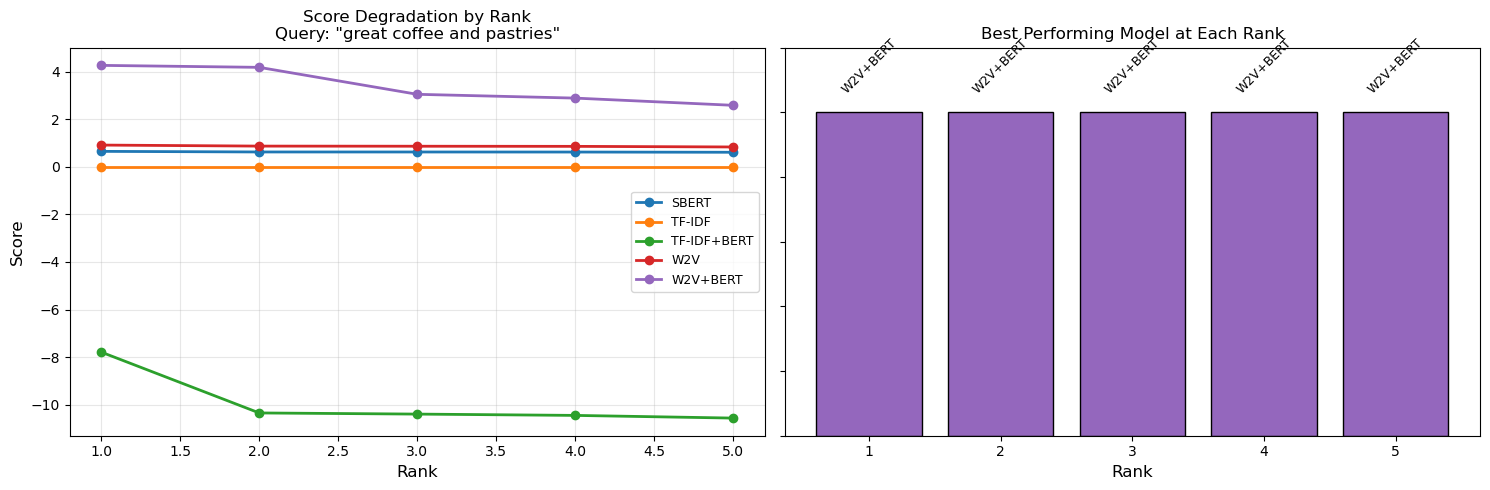

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# simple comparison plot for the current query
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Score comparison
models_short = ['SBERT', 'TF-IDF', 'TF-IDF+BERT', 'W2V', 'W2V+BERT']
all_results = [embeddings_results, tfidf_results, tfidf_bert_results, w2v_results, w2v_bert_results]
scores_matrix = [[r['score'] for r in results] for results in all_results]

for i, (model, scores) in enumerate(zip(models_short, scores_matrix)):
    axes[0].plot(range(1, 6), scores, marker='o', label=model, linewidth=2)

axes[0].set_xlabel('Rank', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title(f'Score Degradation by Rank\nQuery: "{query[:50]}"', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Subplot 2: Best model at each rank
best_models = []
for rank in range(5):
    rank_scores = [scores_matrix[i][rank] for i in range(5)]
    best_models.append(models_short[np.argmax(rank_scores)])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_map = {model: colors[i] for i, model in enumerate(models_short)}
bar_colors = [color_map[m] for m in best_models]

bars = axes[1].bar(range(1, 6), [1]*5, color=bar_colors, edgecolor='black')
axes[1].set_xlabel('Rank', fontsize=12)
axes[1].set_title('Best Performing Model at Each Rank', fontsize=12)
axes[1].set_ylim(0, 1.2)
axes[1].set_yticklabels([])

for bar, model in zip(bars, best_models):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                model, ha='center', va='bottom', fontsize=9, rotation=45)

plt.tight_layout()
plt.savefig('current_query_analysis.png', dpi=150, bbox_inches='tight')
plt.show()